# Introducción

##### Este proyecto analiza el dataset **"Most Streamed Spotify Songs 2024"** (fuente: [Kaggle](https://www.kaggle.com/datasets/nelgiriyewithana/most-streamed-spotify-songs-2024)), que contiene información sobre las canciones más escuchadas en Spotify durante el año 2024, incluyendo métricas de otras plataformas como YouTube y TikTok.
##### El objetivo es aplicar un pipeline completo de análisis de datos: limpieza y transformación con Python, seguido de un análisis exploratorio orientado a responder preguntas concretas sobre el comportamiento del streaming musical.
##### Antes del análisis, se realiza una etapa de limpieza que incluye corrección de tipos de datos, eliminación de columnas con alta proporción de valores nulos y remoción de duplicados, dejando el dataset en condiciones óptimas para su exploración.
##### Las preguntas que guían este análisis buscan entender qué patrones definen el éxito en la plataforma, si la viralidad en redes sociales se traduce en streams reales y si las canciones que dominaron en 2024 fueron más modernas o antiguas.

In [1]:
import os
from dotenv import load_dotenv
from sqlalchemy import create_engine, URL
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Carga del dataset

In [2]:
load_dotenv()
user = os.getenv('USER')
password = os.getenv('PASSWORD')
port = os.getenv('PORT')
hostname = os.getenv('HOSTNAME')

In [3]:
url_object = URL.create(
    drivername="mysql+mysqlconnector",
    username=os.getenv('USER'),
    password=os.getenv('PASSWORD'),
    host=os.getenv('HOSTNAME'),
    port=os.getenv('PORT'),
    database="spotify_2024_database"
)

engine = create_engine(url_object)

pd.set_option('display.max_columns', None)
df = pd.read_sql("SELECT * FROM spotify_songs_2024", engine)
df

,Track,Album Name,Artist,Release Date,ISRC,All Time Rank,Track Score,Spotify Streams,Spotify Playlist Count,Spotify Playlist Reach,Spotify Popularity,YouTube Views,YouTube Likes,TikTok Posts,TikTok Likes,TikTok Views,YouTube Playlist Reach,Apple Music Playlist Count,AirPlay Spins,SiriusXM Spins,Deezer Playlist Count,Deezer Playlist Reach,Amazon Playlist Count,Pandora Streams,Pandora Track Stations,Soundcloud Streams,Shazam Counts,TIDAL Popularity,Explicit Track
0,MILLION DOLLAR BABY,Million Dollar Baby - Single,Tommy Richman,4/26/2024,QM24S2402528,1,725.4,"390,470,936","30,716","196,631,588",92,"84,274,754","1,713,126","5,767,700","651,565,900","5,332,281,936","150,597,040",210,"40,975",684,62,"17,598,718",114,"18,004,655","22,931","4,818,457","2,669,262",,0
1,Not Like Us,Not Like Us,Kendrick Lamar,5/4/2024,USUG12400910,2,545.9,"323,703,884","28,113","174,597,137",92,"116,347,040","3,486,739","674,700","35,223,547","208,339,025","156,380,351",188,"40,778",3,67,"10,422,430",111,"7,780,028","28,444","6,623,075","1,118,279",,1
2,i like the way you kiss me,I like the way you kiss me,Artemas,3/19/2024,QZJ842400387,3,538.4,"601,309,283","54,331","211,607,669",92,"122,599,116","2,228,730","3,025,400","275,154,237","3,369,120,610","373,784,955",190,"74,333",536,136,"36,321,847",172,"5,022,621","5,639","7,208,651","5,285,340",,0
3,Flowers,Flowers - Single,Miley Cyrus,1/12/2023,USSM12209777,4,444.9,"2,031,280,633","269,802","136,569,078",85,"1,096,100,899","10,629,796","7,189,811","1,078,757,968","14,603,725,994","3,351,188,582",394,"1,474,799","2,182",264,"24,684,248",210,"190,260,277","203,384",,"11,822,942",,0
4,Houdini,Houdini,Eminem,5/31/2024,USUG12403398,5,423.3,"107,034,922","7,223","151,469,874",88,"77,373,957","3,670,188","16,400",,,"112,763,851",182,"12,185",1,82,"17,660,624",105,"4,493,884","7,006","207,179","457,017",,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4595,For the Last Time,For the Last Time,$uicideboy$,9/5/2017,QM8DG1703420,"4,585",19.4,"305,049,963","65,770","5,103,054",71,"149,247,747","1,397,590","48,370","20,202,000","143,934,379","53,016",3,6,,2,"14,217",,"20,104,066","13,184","50,633,006","656,337",,1
4596,Dil Meri Na Sune,"Dil Meri Na Sune (From ""Genius"""")""",Atif Aslam,7/27/2018,INT101800122,"4,575",19.4,"52,282,360","4,602","1,449,767",56,"943,920,245","5,347,766",,"1,721","19,935","24,973,048",1,412,,1,927,,,,,"193,590",,0
4597,Grace (feat. 42 Dugg),My Turn,Lil Baby,2/28/2020,USUG12000043,"4,571",19.4,"189,972,685","72,066","6,704,802",65,"201,027,333","1,081,402","7,596","5,288,677","36,849,005","29,253,152",19,204,,1,74,6,"84,426,740","28,999",,"1,135,998",,1
4598,Nashe Si Chadh Gayi,November Top 10 Songs,Arijit Singh,11/8/2016,INY091600067,"4,591",19.4,"145,467,020","14,037","7,387,064",66,"1,118,595,159","3,868,828","11,433","2,534,831","37,757,301","25,150,516",1,"1,200",,,,7,"6,817,840",,,"448,292",,0


# Limpieza del dataset

In [4]:
df_info = pd.read_sql("SHOW COLUMNS FROM spotify_songs_2024", engine)
df_info

,Field,Type,Null,Key,Default,Extra
0,Track,text,YES,,None,
1,Album Name,text,YES,,None,
2,Artist,text,YES,,None,
3,Release Date,text,YES,,None,
4,ISRC,text,YES,,None,
5,All Time Rank,text,YES,,None,
6,Track Score,double,YES,,None,
7,Spotify Streams,text,YES,,None,
8,Spotify Playlist Count,text,YES,,None,
9,Spotify Playlist Reach,text,YES,,None,


#### Se corrige el tipo de dato de las columnas

In [5]:
columnas_int = ['All Time Rank', 'Spotify Streams', 'Spotify Playlist Count', 'Spotify Playlist Reach', 'Spotify Popularity',
                 'YouTube Views', 'YouTube Likes', 'TikTok Posts', 'TikTok Likes', 'TikTok Views', 'YouTube Playlist Reach', 
                 'Apple Music Playlist Count', 'AirPlay Spins', 'SiriusXM Spins', 'Deezer Playlist Count', 'Deezer Playlist Reach', 'Amazon Playlist Count',
                 'Pandora Streams', 'Pandora Track Stations', 'Soundcloud Streams', 'Shazam Counts', 'TIDAL Popularity']

In [6]:
# Columnas que pasan a int
for col in columnas_int:
    df[col] = df[col].astype(str).str.replace(',', '').str.strip()
    df[col] = pd.to_numeric(df[col], errors='coerce').astype('Int64')

# Columna que pasa a bin
df['Explicit Track'] = df['Explicit Track'].astype(int).astype(bool)

# Columna que pasa a formato fecha
df['Release Date'] = pd.to_datetime(df['Release Date'], dayfirst=True)

C:\Users\augus\AppData\Local\Temp\ipykernel_18924\1304870194.py:10: UserWarning: Parsing dates in %m/%d/%Y format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df['Release Date'] = pd.to_datetime(df['Release Date'], dayfirst=True)


In [7]:
df.dtypes

Track                                 object
Album Name                            object
Artist                                object
Release Date                  datetime64[ns]
ISRC                                  object
All Time Rank                          Int64
Track Score                          float64
Spotify Streams                        Int64
Spotify Playlist Count                 Int64
Spotify Playlist Reach                 Int64
Spotify Popularity                     Int64
YouTube Views                          Int64
YouTube Likes                          Int64
TikTok Posts                           Int64
TikTok Likes                           Int64
TikTok Views                           Int64
YouTube Playlist Reach                 Int64
Apple Music Playlist Count             Int64
AirPlay Spins                          Int64
SiriusXM Spins                         Int64
Deezer Playlist Count                  Int64
Deezer Playlist Reach                  Int64
Amazon Pla

#### Se eliminan las 3 columnas con más del 30% de valores nulos

In [8]:
print('Porcentaje de valores nulos en cada columna:')
nulos = (df.isnull().sum() / len(df)).round(2)
nulos.sort_values(ascending=False)

Porcentaje de valores nulos en cada columna:


TIDAL Popularity              1.00
Soundcloud Streams            0.72
SiriusXM Spins                0.46
Pandora Track Stations        0.28
TikTok Posts                  0.26
Pandora Streams               0.24
Amazon Playlist Count         0.23
YouTube Playlist Reach        0.22
TikTok Likes                  0.21
TikTok Views                  0.21
Deezer Playlist Count         0.20
Deezer Playlist Reach         0.20
Spotify Popularity            0.17
Shazam Counts                 0.13
Apple Music Playlist Count    0.12
AirPlay Spins                 0.11
YouTube Views                 0.07
YouTube Likes                 0.07
Spotify Playlist Reach        0.02
Spotify Playlist Count        0.02
Spotify Streams               0.02
Track                         0.00
Album Name                    0.00
Track Score                   0.00
All Time Rank                 0.00
ISRC                          0.00
Release Date                  0.00
Artist                        0.00
Explicit Track      

In [9]:
print('Columnas no confiables (más del 30% nulos)')
nulos[nulos < 0.70].sort_values()

Columnas no confiables (más del 30% nulos)


Track                         0.00
Track Score                   0.00
All Time Rank                 0.00
ISRC                          0.00
Explicit Track                0.00
Artist                        0.00
Album Name                    0.00
Release Date                  0.00
Spotify Streams               0.02
Spotify Playlist Count        0.02
Spotify Playlist Reach        0.02
YouTube Views                 0.07
YouTube Likes                 0.07
AirPlay Spins                 0.11
Apple Music Playlist Count    0.12
Shazam Counts                 0.13
Spotify Popularity            0.17
Deezer Playlist Reach         0.20
Deezer Playlist Count         0.20
TikTok Views                  0.21
TikTok Likes                  0.21
YouTube Playlist Reach        0.22
Amazon Playlist Count         0.23
Pandora Streams               0.24
TikTok Posts                  0.26
Pandora Track Stations        0.28
SiriusXM Spins                0.46
dtype: float64

In [10]:
# Se eliminan columnas no confiables
df = df.drop(columns=['TIDAL Popularity', 'Soundcloud Streams', 'SiriusXM Spins'])

In [11]:
print(f'Columnas restantes: {df.shape[1]}')
df.head()


Columnas restantes: 26


,Track,Album Name,Artist,Release Date,ISRC,All Time Rank,Track Score,Spotify Streams,Spotify Playlist Count,Spotify Playlist Reach,Spotify Popularity,YouTube Views,YouTube Likes,TikTok Posts,TikTok Likes,TikTok Views,YouTube Playlist Reach,Apple Music Playlist Count,AirPlay Spins,Deezer Playlist Count,Deezer Playlist Reach,Amazon Playlist Count,Pandora Streams,Pandora Track Stations,Shazam Counts,Explicit Track
0,MILLION DOLLAR BABY,Million Dollar Baby - Single,Tommy Richman,2024-04-26,QM24S2402528,1,725.4,390470936,30716,196631588,92,84274754,1713126,5767700,651565900,5332281936,150597040,210,40975,62,17598718,114,18004655,22931,2669262,False
1,Not Like Us,Not Like Us,Kendrick Lamar,2024-05-04,USUG12400910,2,545.9,323703884,28113,174597137,92,116347040,3486739,674700,35223547,208339025,156380351,188,40778,67,10422430,111,7780028,28444,1118279,True
2,i like the way you kiss me,I like the way you kiss me,Artemas,2024-03-19,QZJ842400387,3,538.4,601309283,54331,211607669,92,122599116,2228730,3025400,275154237,3369120610,373784955,190,74333,136,36321847,172,5022621,5639,5285340,False
3,Flowers,Flowers - Single,Miley Cyrus,2023-01-12,USSM12209777,4,444.9,2031280633,269802,136569078,85,1096100899,10629796,7189811,1078757968,14603725994,3351188582,394,1474799,264,24684248,210,190260277,203384,11822942,False
4,Houdini,Houdini,Eminem,2024-05-31,USUG12403398,5,423.3,107034922,7223,151469874,88,77373957,3670188,16400,<NA>,<NA>,112763851,182,12185,82,17660624,105,4493884,7006,457017,True


In [12]:
pd.reset_option('display.max_columns')

#### Se eliminan duplicados

In [13]:
print(f"Filas antes de eliminar duplicados: {df.shape[0]}")
df = df.sort_values('Spotify Streams', ascending=False).drop_duplicates(subset=['Track', 'Artist'], keep='first')
print(f"Filas después de eliminar duplicados: {df.shape[0]}")

Filas antes de eliminar duplicados: 4600
Filas después de eliminar duplicados: 4488


In [14]:
# Estadísticas básicas de las columnas numéricas
df.describe()

,Release Date,All Time Rank,Track Score,Spotify Streams,Spotify Playlist Count,Spotify Playlist Reach,Spotify Popularity,YouTube Views,YouTube Likes,TikTok Posts,...,TikTok Views,YouTube Playlist Reach,Apple Music Playlist Count,AirPlay Spins,Deezer Playlist Count,Deezer Playlist Reach,Amazon Playlist Count,Pandora Streams,Pandora Track Stations,Shazam Counts
count,4488,4488.0,4488.000000,4389.0,4433.0,4431.0,3745.0,4235.0,4228.0,3396.0,...,3586.0,3539.0,3969.0,4038.0,3624.0,3617.0,3496.0,3464.0,3303.0,3993.0
mean,2021-01-25 16:45:52.941176576,2299.931373,41.457531,433529955.316017,59672.733589,23463794.997292,63.604005,396171895.704132,2884354.842006,934720.477621,...,1138472622.513664,337125015.111331,53.964979,53638.365775,32.278422,1291053.159524,25.222254,84631778.612009,87028.038147,2509822.69722
min,1987-07-21 00:00:00,1.0,19.400000,1071.0,1.0,1.0,1.0,913.0,25.0,1.0,...,19.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,1.0,1.0
25%,2019-07-18 18:00:00,1149.75,23.300000,68411628.0,7125.0,5056398.0,61.0,40364935.0,407623.75,37712.0,...,58166043.5,11467972.5,10.0,473.5,5.0,53340.0,8.0,1035433.0,1231.5,230257.0
50%,2022-05-22 00:00:00,2308.0,29.800000,231981539.0,32989.0,13487736.0,67.0,147259041.0,1250975.0,181530.0,...,264033716.0,96467771.0,27.0,5792.5,15.0,237821.0,17.0,12498115.5,7638.0,850346.0
75%,2023-08-10 00:00:00,3444.25,44.300000,607315454.0,86820.0,29859838.0,73.0,459302188.5,3547368.5,792127.75,...,907309974.25,302814785.5,69.0,45000.75,37.0,903632.0,34.0,80658493.5,48351.5,2665347.0
max,2024-06-14 00:00:00,4998.0,725.400000,4281468720.0,590392.0,262343414.0,96.0,16322756555.0,62311179.0,42900000.0,...,233232311463.0,7289707052.0,859.0,1777811.0,632.0,48197850.0,189.0,1463624043.0,3780513.0,219794543.0
std,NaN,1322.267206,37.444037,523804745.710814,70584.213709,29603170.34995,16.000165,694717657.083565,4551468.81829,2428059.457578,...,5867509184.209497,662859593.370337,70.661745,123505.371631,54.274758,3548201.39007,25.678815,165872892.464872,260456.34674,6027312.714383


In [15]:
# Para crear el csv limpio
df.to_csv('spotify_clean.csv', index=False)

# Análisis con preguntas y gráficos

#### Las 10 canciones más escuchadas de Spotify

In [16]:
# Voy a filtrar los tracks que son covers o remixes de otros artistas para dejar solo los originales
top10_canciones_spotify = (df.sort_values('Spotify Streams', ascending=False)
                           .drop_duplicates(subset='Track', keep='first')
                           .nlargest(10, 'Spotify Streams')[['Track', 'Artist', 'Spotify Streams']]) 
top10_canciones_spotify['Track'] = top10_canciones_spotify['Track'] + ' - ' + top10_canciones_spotify['Artist']
top10_canciones_spotify

,Track,Artist,Spotify Streams
55,Blinding Lights - The Weeknd,The Weeknd,4281468720
53,Shape of You - Ed Sheeran,Ed Sheeran,3909458734
132,Someone You Loved - Lewis Capaldi,Lewis Capaldi,3427498835
114,Sunflower - Spider-Man: Into the Spider-Verse ...,Post Malone,3358704125
19,As It Was - Harry Styles,Harry Styles,3301814535
262,Starboy - The Weeknd,The Weeknd,3291262413
519,One Dance - Drake,Drake,3192204066
2397,STAY (with Justin Bieber) - The Kid LAROI,The Kid LAROI,3107100349
39,Dance Monkey - Tones And I,Tones And I,3071214106
118,Believer - Imagine Dragons,Imagine Dragons,3006226762


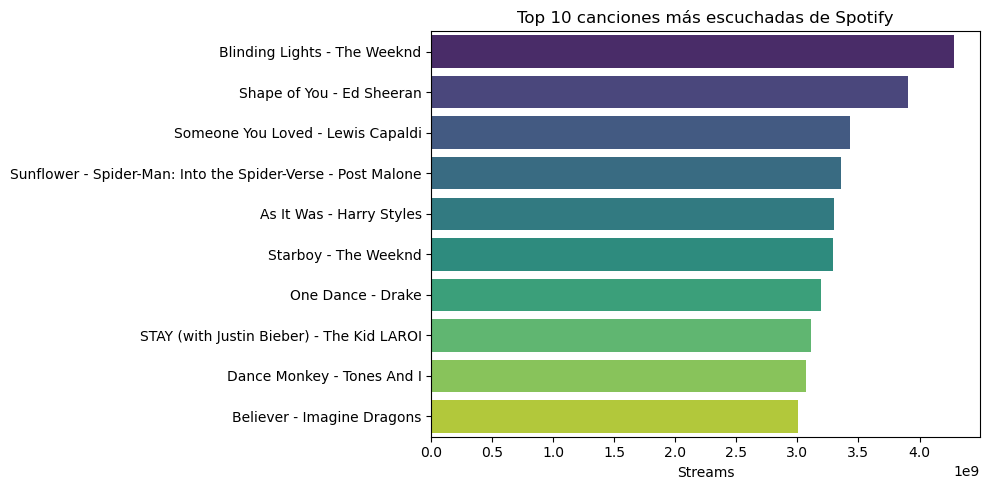

In [17]:
plt.figure(figsize=(10, 5))
sns.barplot(data=top10_canciones_spotify, x='Spotify Streams', y='Track', hue='Track', palette='viridis', legend=False)
plt.title('Top 10 canciones más escuchadas de Spotify')
plt.xlabel('Streams')
plt.ylabel('')
plt.tight_layout()
plt.show()

#### ¿Quiénes son los 10 artistas con más streams en Spotify?

In [18]:
top10_artistas_spotify = df.groupby('Artist')['Spotify Streams'].sum().nlargest(10).reset_index()
top10_artistas_spotify

,Artist,Spotify Streams
0,Bad Bunny,36336985388
1,The Weeknd,34141482745
2,Drake,33449494286
3,Taylor Swift,33232649565
4,Ed Sheeran,24014900390
5,Post Malone,23933989014
6,Ariana Grande,23048177700
7,Imagine Dragons,17157121647
8,Billie Eilish,16811833201
9,Justin Bieber,16647801287


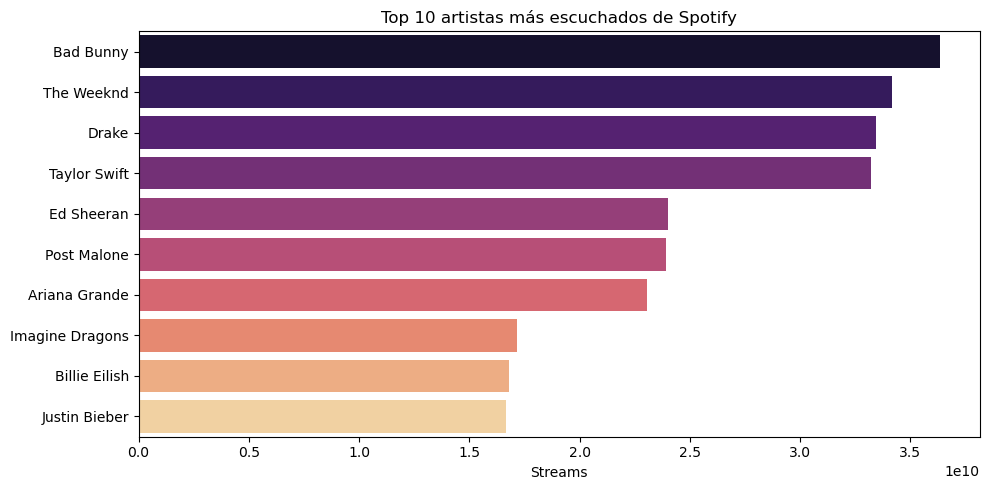

In [19]:
plt.figure(figsize=(10, 5))
sns.barplot(data=top10_artistas_spotify, x='Spotify Streams', y='Artist', hue='Artist', palette='magma', legend=False)
plt.title('Top 10 artistas más escuchados de Spotify')
plt.xlabel('Streams')
plt.ylabel('')
plt.tight_layout()
plt.show()

In [20]:
bad_bunny = df[df['Artist'] == 'Bad Bunny'][['Track', 'Spotify Streams']].sort_values('Spotify Streams', ascending=False)
print(f'Canciones de Bad Bunny en el dataset: {len(bad_bunny)}')
bad_bunny.head(10)

Canciones de Bad Bunny en el dataset: 59


,Track,Spotify Streams
261,Dakiti,1977947460
63,Me Porto Bonito,1811990630
88,Titï¿½ï¿½ Me Pregu,1514239759
642,Callaita,1448173030
187,Ojitos Lindos,1421763497
294,Yonaguni,1398634184
504,MIA (feat. Drake),1318254846
290,Efecto,1293773697
271,Moscow Mule,1108031580
1707,Vete,991885224


**Dato curioso:** A pesar de que Bad Bunny aparece como el artista más escuchado, ninguna de sus canciones logra llegar a los 2 billones, por lo que ninguna de ellas llega al top 10 de las más escuchadas. Esto me lleva a la siguiente pregunta.

#### Modelos de éxito: ¿Dominan los artistas por volumen de canciones o por hits?

In [21]:
top10_nombres = df.groupby('Artist')['Spotify Streams'].sum().nlargest(10).index

resumen = df[df['Artist'].isin(top10_nombres)].groupby('Artist').agg(cantidad_canciones=('Track', 'count'), 
                                                                     streams_totales=('Spotify Streams', 'sum'), 
                                                                     mejor_cancion_streams=('Spotify Streams', 'max')).sort_values('streams_totales', ascending=False)

resumen

,cantidad_canciones,streams_totales,mejor_cancion_streams
Artist,,,
Bad Bunny,59,36336985388,1977947460
The Weeknd,29,34141482745,4281468720
Drake,59,33449494286,3192204066
Taylor Swift,60,33232649565,2188247133
Ed Sheeran,15,24014900390,3909458734
Post Malone,20,23933989014,3358704125
Ariana Grande,25,23048177700,2262490403
Imagine Dragons,16,17157121647,3006226762
Billie Eilish,27,16811833201,2516804300


In [22]:
df_modelo = df.groupby('Artist').agg(total_streams=('Spotify Streams', 'sum'), canciones=('Track', 'nunique')).reset_index()

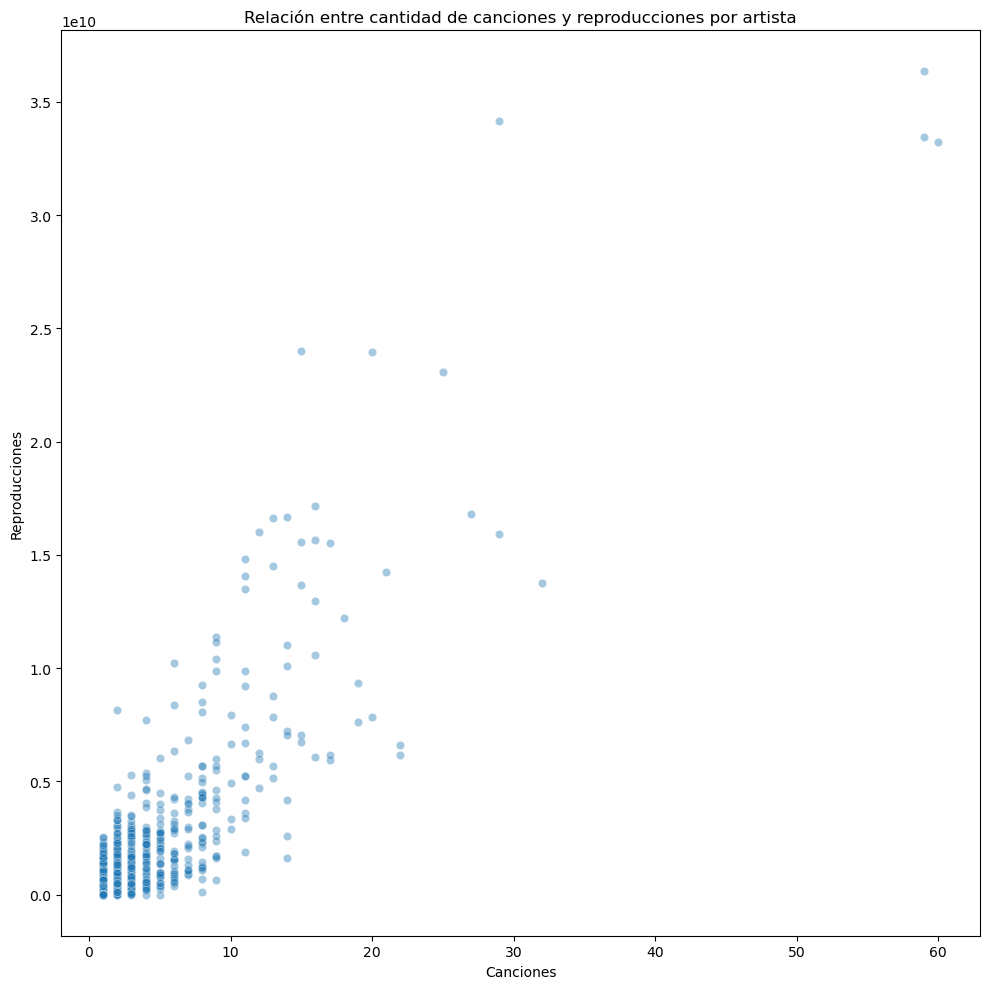

In [23]:
plt.figure(figsize=(10, 10))
sns.scatterplot(data=df_modelo, x='canciones', y='total_streams', alpha=0.4)
plt.title('Relación entre cantidad de canciones y reproducciones por artista')
plt.xlabel('Canciones')
plt.ylabel('Reproducciones')
plt.tight_layout()
plt.show()

In [24]:
correlacion = df_modelo['total_streams'].corr(df_modelo['canciones'])
print(f'Correlación entre reproducciones y cantidad de canciones: {correlacion:.2f}')

Correlación entre reproducciones y cantidad de canciones: 0.87


**Conclusión:** 
* Es evidente que existen dos modelos de éxito distintos en Spotify. Sin embargo, el más notorio es el de volumen de tracks.
* Artistas como Bad Bunny, Drake y Taylor Swift dominan por volumen tienen 59-60 canciones cada uno en el top global. 
* Ed Sheeran y The Weeknd llegan al top 10 con catálogos mucho más chicos pero sostenidos por hits individuales como Shape of You (3.9B) y Blinding Lights (4.3B).
* Hay una fuerte correlación (87%) entre la cantidad de canciones y las reproducciones totales que puede tener un artista.

#### ¿Las canciones virales en TikTok también dominan en Spotify?

In [25]:
# Hay outliers que distorsionan el gráfico, así que los voy a eliminar
df.nlargest(5, 'TikTok Views')[['Track', 'Artist', 'Spotify Streams', 'TikTok Views']]
# Al parecer, estos outliers son porque se usan estas canciones muy seguido en memes de TikTok y se repiten constantemente. Pero en Spotify no tienen ni de cerca esas reproducciones

,Track,Artist,Spotify Streams,TikTok Views
1024,Monkeys Spinning Monkeys,Kevin MacLeod,11477477,233232311463
1922,Love You So,The King Khan & BBQ Show,16326628,214843956590
474,Oh No,Kreepa,40284121,61088562861
1547,Funny Song,Cavendish Music,5866282,38373644011
113,Aesthetic,Tollan Kim,5712985,33870791454


In [26]:
df_tiktok = df[['Track', 'Artist', 'TikTok Views', 'Spotify Streams']].dropna()
df_tiktok = df_tiktok[df_tiktok['TikTok Views'] < 2e10]
df_tiktok = df_tiktok[df_tiktok['Spotify Streams'] < 35e8]
df_tiktok 

,Track,Artist,TikTok Views,Spotify Streams
132,Someone You Loved,Lewis Capaldi,2161032034,3427498835
114,Sunflower - Spider-Man: Into the Spider-Verse,Post Malone,1597453878,3358704125
19,As It Was,Harry Styles,15405881843,3301814535
262,Starboy,The Weeknd,375498232,3291262413
519,One Dance,Drake,388544079,3192204066
...,...,...,...,...
4280,Mua!,Barracca Republic,504872722,3739
4490,Fadeaway,BCD Studio,1319467906,3711
2959,He Ya Pyar Sajena,TOADI,312937612,3574
4508,Happy Birthday,YolyBoy,166506168,1761


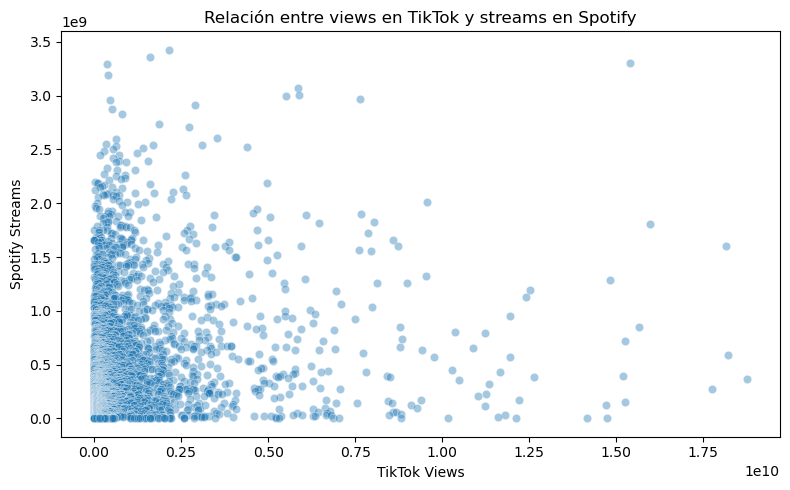

In [27]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_tiktok, x='TikTok Views', y='Spotify Streams', alpha=0.4)
plt.title('Relación entre views en TikTok y streams en Spotify')
plt.xlabel('TikTok Views')
plt.ylabel('Spotify Streams')
plt.tight_layout()
plt.show()

In [28]:
correlacion = df_tiktok['TikTok Views'].corr(df_tiktok['Spotify Streams'])
print(f'Correlación Tiktok Views VS Spotify Streams: {correlacion:.2f}')

Correlación Tiktok Views VS Spotify Streams: 0.15


**Conclusión:** 
* No existe una correlación entre la popularidad en TikTok y los streams en Spotify. El coeficiente de correlación de Pearson entre TikTok Views y Spotify Streams es de apenas un 15%.
* Las canciones más virales en TikTok suelen ser tracks de fondo usados en memes (como "Monkeys Spinning Monkeys") 
que acumulan billones de views pero apenas millones de streams en Spotify.



#### ¿Las canciones virales en YouTube también dominan en Spotify?

In [29]:
df_yt = df[['Track', 'Artist', 'YouTube Views', 'Spotify Streams']].dropna()
df_yt = df_yt[df_yt['YouTube Views'] < 6e9]
df_yt = df_yt[df_yt['Spotify Streams'] < 35e8]
df_yt

,Track,Artist,YouTube Views,Spotify Streams
132,Someone You Loved,Lewis Capaldi,2153701892,3427498835
114,Sunflower - Spider-Man: Into the Spider-Verse,Post Malone,2763188773,3358704125
19,As It Was,Harry Styles,800899315,3301814535
262,Starboy,The Weeknd,2829990867,3291262413
519,One Dance,Drake,456806913,3192204066
...,...,...,...,...
61,Very Cute Melody by Marimba Tone (39813),mitsu sound,222076,1384
1768,No Fuss,Zeme Libre,411286256,1332
4039,Numero Uno,Dan-E-MC,389845206,1224
356,6. A.M.,Azul,1231300374,1186


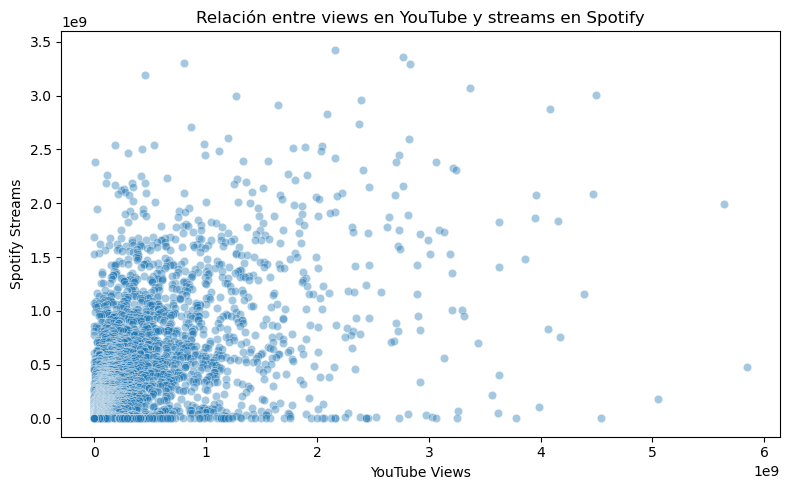

In [30]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_yt, x='YouTube Views', y='Spotify Streams', alpha=0.4)
plt.title('Relación entre views en YouTube y streams en Spotify')
plt.xlabel('YouTube Views')
plt.ylabel('Spotify Streams')
plt.tight_layout()
plt.show()

In [31]:
correlacion = df_yt['YouTube Views'].corr(df_yt['Spotify Streams'])
print(f'Correlación YouTube Views VS Spotify Streams: {correlacion:.2f}')

Correlación YouTube Views VS Spotify Streams: 0.50


**Conclusión:** 
* YouTube muestra una correlación moderada con Spotify (0.50), significativamente mayor que TikTok (0.15). 
* Esto refleja una gran diferencia entre plataformas: YouTube y Spotify comparten un usuario que busca música activamente, 
mientras que TikTok viraliza canciones como fondo de videos.
* Una canción exitosa en Spotify tiene más chances de serlo en YouTube 
que en TikTok, pero la correlación moderada (50%) indica que cada plataforma sigue teniendo su propia dinámica de consumo.

#### ¿Las canciones explícitas tienen más streams que las no explícitas?

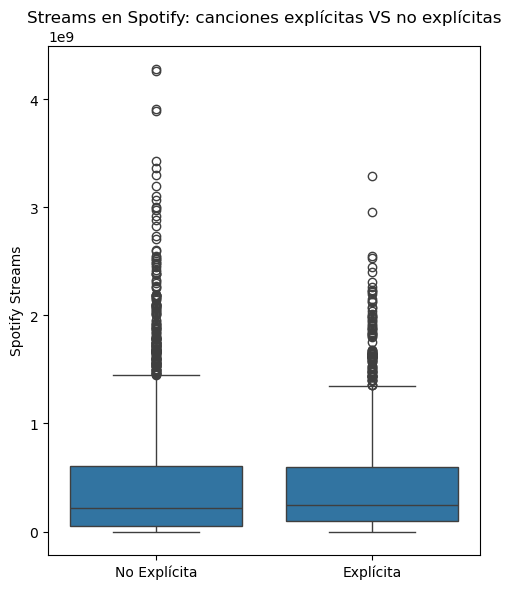

In [32]:
df['Explicit Label'] = df['Explicit Track'].map({True: 'Explícita', False: 'No Explícita'})

plt.figure(figsize=(5, 6))
sns.boxplot(data=df, x='Explicit Label', y='Spotify Streams')
plt.title('Streams en Spotify: canciones explícitas VS no explícitas')
plt.xlabel('')
plt.ylabel('Spotify Streams')
plt.tight_layout()
plt.show()

In [33]:
print('Mediana entre explícitas y no explícitas')
df.groupby('Explicit Label')['Spotify Streams'].median()

Mediana entre explícitas y no explícitas


Explicit Label
Explícita       246425341.0
No Explícita    221995583.0
Name: Spotify Streams, dtype: Float64

In [34]:
print('Promedio entre explícitas y no explícitas')
df.groupby('Explicit Label')['Spotify Streams'].mean()

Promedio entre explícitas y no explícitas


Explicit Label
Explícita        424519868.83883
No Explícita    438734559.546369
Name: Spotify Streams, dtype: Float64

**Conclusión:** 
* Las canciones explícitas tienen una mediana de streams levemente superior (248M vs 219M) y un promedio levemente inferior (430M VS 434M). 
* El contenido explícito no parece ser un factor determinante en la popularidad de una canción en Spotify.

#### ¿En qué año se lanzaron las canciones que dominaron durante 2024?

In [35]:
df['Release Year'] = df['Release Date'].dt.year # Creo columna de años

canciones_por_año = df.groupby('Release Year')['Spotify Streams'].sum().reset_index()
canciones_por_año.columns = ['Año', 'Spotify Streams']

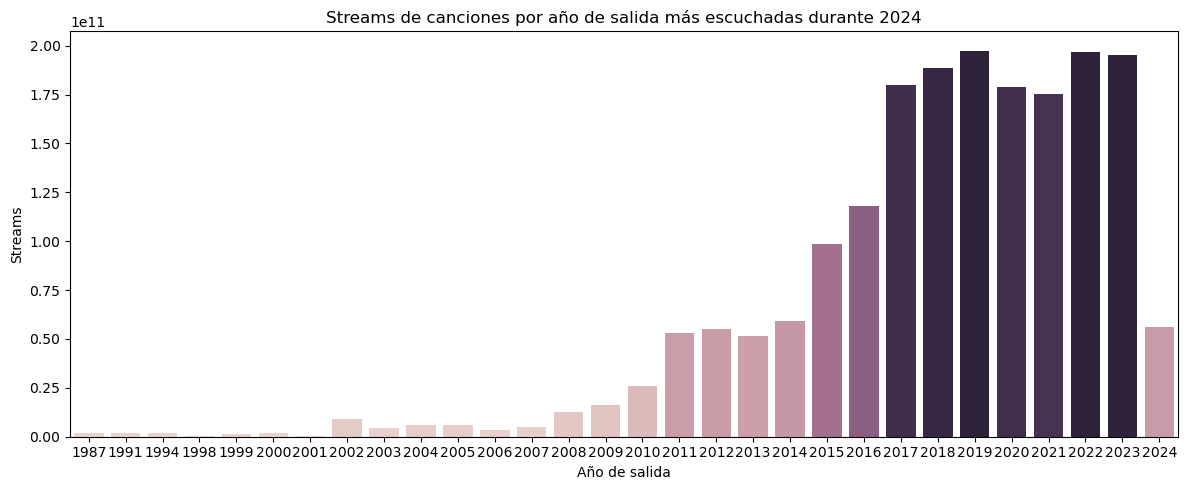

In [36]:
plt.figure(figsize=(12, 5))
sns.barplot(data=canciones_por_año, x='Año', y='Spotify Streams', hue='Spotify Streams', legend=False)
plt.title('Streams de canciones por año de salida más escuchadas durante 2024')
plt.xlabel('Año de salida')
plt.ylabel('Streams')
plt.tight_layout()
plt.show()

In [37]:
canciones_por_año.nlargest(1, 'Spotify Streams')

,Año,Spotify Streams
24,2019,197469458194


**Conclusión:** 
* Las canciones lanzadas en 2019 son las que mayor cantidad de streams tienen acumulados durante 2024. 
* También se puede ver como todo el periodo 2017-2023 es el que más dominó. 2024 se podría descartar porque las canciones salidas durante ese año no tuvieron tanto tiempo para acumular streams como las de años anteriores.

# Conclusión final:
##### El modelo de éxito: El modelo no es único, coexisten artistas que acumulan streams gracias a un catálogo grande y otros que lo hacen con pocos hits pero de un alto impacto. Ambas estrategias funcionan. Sin embargo, puede verse una dominancia casi total del modelo de volumen.
##### Sobre la viralidad: La correlación entre viralidad en TikTok y streams en Spotify no existe y, en YouTube la correlación existe, pero no es determinante. Una canción puede ser viral sin dominar el streaming, y viceversa.
##### Sobre el contenido explícito: El contenido explícito no parece ser un factor determinante en la popularidad de una canción en Spotify.
##### Sobre el éxito musical: El streaming en 2024 premió más la novedad sobre la longevidad. Se puede ver que hay una concentración de streams de canciones lanzadas durante 2017-2023.
